MAE  : $15,741.75
RMSE : $20,027.40
R²   : 0.9152


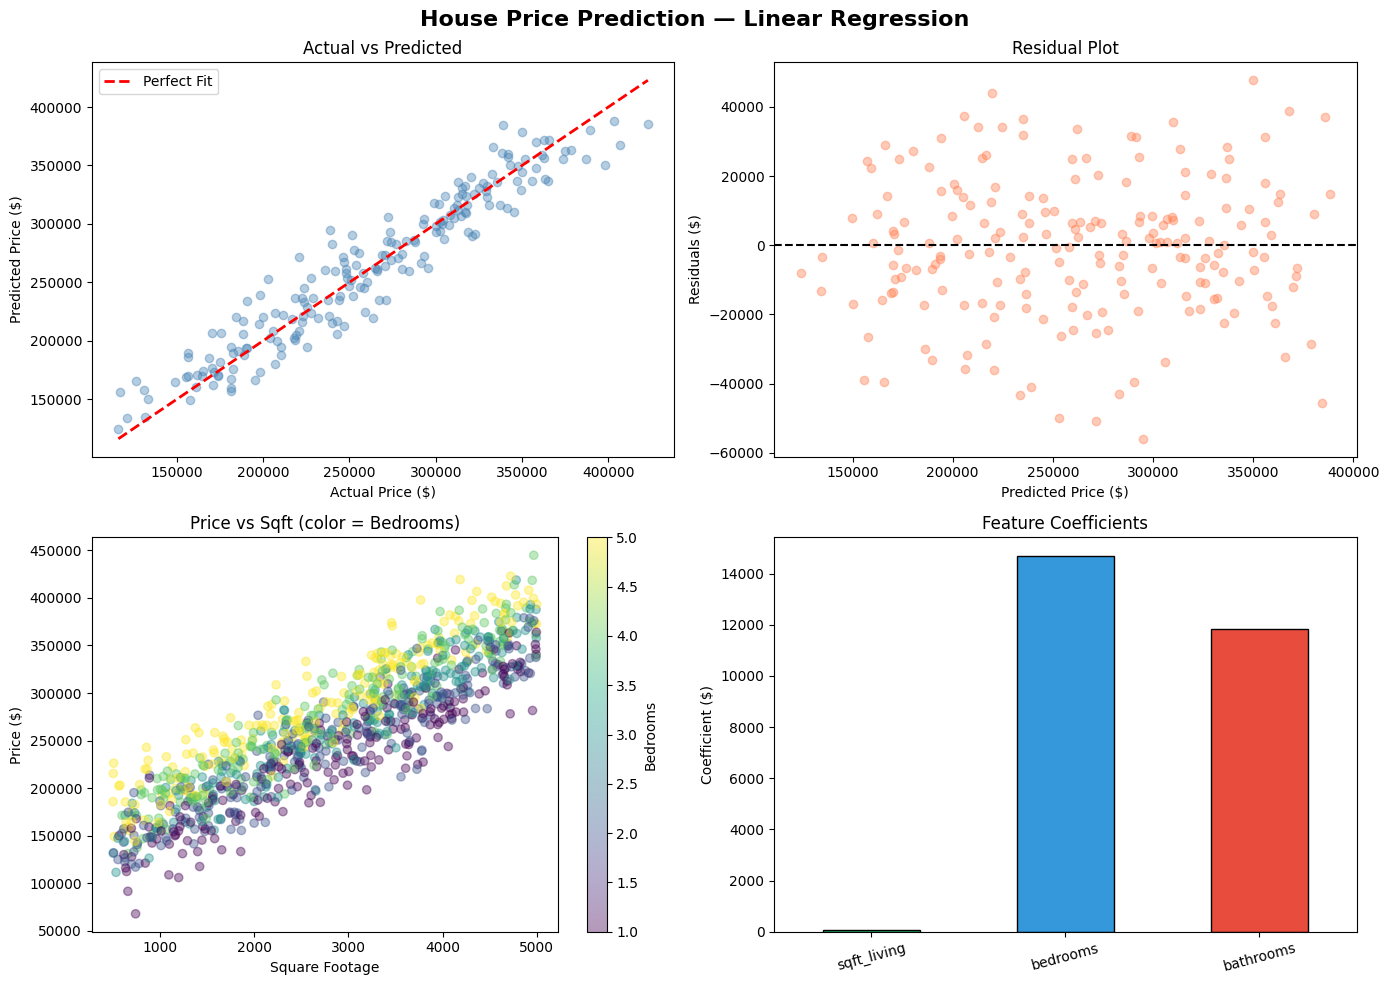

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

# ─────────────────────────────────────────────
# 1. Generate Dataset
# ─────────────────────────────────────────────
np.random.seed(42)
n = 1000

sqft      = np.random.randint(500, 5000, n)
bedrooms  = np.random.randint(1, 6, n)
bathrooms = np.random.randint(1, 4, n)

price = (
    50 * sqft
    + 15000 * bedrooms
    + 12000 * bathrooms
    + np.random.normal(0, 20000, n)
    + 50000
).clip(min=50000)

df = pd.DataFrame({
    'sqft_living': sqft,
    'bedrooms':    bedrooms,
    'bathrooms':   bathrooms,
    'price':       price
})

# ─────────────────────────────────────────────
# 2. Features & Target Split
# ─────────────────────────────────────────────
X = df[['sqft_living', 'bedrooms', 'bathrooms']]
y = df['price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ─────────────────────────────────────────────
# 3. Train Linear Regression Model
# ─────────────────────────────────────────────
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# ─────────────────────────────────────────────
# 4. Evaluate
# ─────────────────────────────────────────────
mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)

print(f"MAE  : ${mae:,.2f}")
print(f"RMSE : ${rmse:,.2f}")
print(f"R²   : {r2:.4f}")

# ─────────────────────────────────────────────
# 5. Visualizations
# ─────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("House Price Prediction — Linear Regression", fontsize=16, fontweight='bold')

# Actual vs Predicted
ax = axes[0, 0]
ax.scatter(y_test, y_pred, alpha=0.4, color='steelblue')
mn, mx = min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())
ax.plot([mn, mx], [mn, mx], 'r--', lw=2, label='Perfect Fit')
ax.set_xlabel("Actual Price ($)"); ax.set_ylabel("Predicted Price ($)")
ax.set_title("Actual vs Predicted"); ax.legend()

# Residuals
residuals = y_test - y_pred
ax = axes[0, 1]
ax.scatter(y_pred, residuals, alpha=0.4, color='coral')
ax.axhline(0, color='black', lw=1.5, linestyle='--')
ax.set_xlabel("Predicted Price ($)"); ax.set_ylabel("Residuals ($)")
ax.set_title("Residual Plot")

# Price vs Sqft
ax = axes[1, 0]
sc = ax.scatter(df['sqft_living'], df['price'], c=df['bedrooms'],
                cmap='viridis', alpha=0.4)
plt.colorbar(sc, ax=ax, label='Bedrooms')
ax.set_xlabel("Square Footage"); ax.set_ylabel("Price ($)")
ax.set_title("Price vs Sqft (color = Bedrooms)")

# Feature Coefficients
ax = axes[1, 1]
coefs = pd.Series(model.coef_, index=X.columns)
coefs.plot(kind='bar', ax=ax, color=['#2ecc71','#3498db','#e74c3c'], edgecolor='black')
ax.set_title("Feature Coefficients"); ax.set_ylabel("Coefficient ($)")
ax.set_xticklabels(coefs.index, rotation=15)

plt.tight_layout()
plt.savefig('house_price_regression.png', dpi=150, bbox_inches='tight')
plt.show()